# Verifying the Outputs of PHYSys -- AMR Addition

After the findings in the previously done [notebook](verify-h5.ipynb), the system was extended to support AMR modulations.

That being said, the current system is *supposed to* return (with the function generate_iq()): 

> **(bits, llr, snr_levels, x, y)**

In this as the naming convention:

* x is the clean transmitted symbols
* y is the noisy received symbols
* bits / llr are still there

### Imports and File Directories

In [132]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erfc

H5_DIR = '../modulations/BPSK'
H5_FILE = H5_DIR + '/sweep.h5'

### Inspection of Metadata and File Structure

In [133]:
h5_file = h5py.File(H5_FILE, 'r')

KEYS = list(h5_file.keys())

print(KEYS)


['bits', 'llr', 'snr_labels', 'x', 'y']


This matches the supposed act of the changed [export.py](../physys/export.py). 

In [134]:
bits_name       = KEYS[0]
llr_name        = KEYS[1]
snr_labels_name = KEYS[2]
x_name          = KEYS[3]
y_name          = KEYS[4]

BITS_DATASET       = h5_file[bits_name]
LLR_DATASET        = h5_file[llr_name]
SNR_LABELS_DATASET = h5_file[snr_labels_name]
X_DATASET          = h5_file[x_name]
Y_DATASET          = h5_file[y_name]

bits            = BITS_DATASET[...]
llrs            = LLR_DATASET[...]
snrs            = SNR_LABELS_DATASET[...]
xs              = X_DATASET[...]
ys              = Y_DATASET[...]

DATA = {

    "bits" : bits,
    "llrs" : llrs, 
    "snrs" : snrs, 
    "xs"   : xs, 
    "ys"   : ys

}


for name, s in DATA.items():

    print(f"---------------- {name} ----------------------")

    print()

    print(f"{name}'s shape                  : {s.dtype}")
    print(f"{name} dtype                    : {s.dtype}")
    print(f"First element of {name}         : {s[0]}")
    print(f"First element's shape  of {name}: {s[0].shape}")

    print()

---------------- bits ----------------------

bits's shape                  : float32
bits dtype                    : float32
First element of bits         : [[0. 1. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 1. 1.]
 [1. 0. 0. ... 1. 1. 1.]
 [0. 0. 0. ... 0. 1. 0.]]
First element's shape  of bits: (4, 1024)

---------------- llrs ----------------------

llrs's shape                  : float32
llrs dtype                    : float32
First element of llrs         : [[ 1.0728071  -0.60825044 -0.96331143 ...  1.0796044   1.3148568
   0.19389081]
 [ 0.2572144  -0.14718175  0.21003988 ... -0.5958967   1.178957
  -0.27747858]
 [ 0.11353707 -0.28796437 -0.05219179 ... -0.31779984  0.15345469
   0.9772085 ]
 [-1.2311683   0.7666807  -0.5224082  ...  0.25137538  0.55377567
  -0.5016842 ]]
First element's shape  of llrs: (4, 1024)

---------------- snrs ----------------------

snrs's shape                  : float64
snrs dtype                    : float64
First element of snrs         : -10.0
First eleme

### Checking metadata

In [135]:
FILE_ATTRS = h5_file.attrs
FILE_ATTRS_KEYS = list(FILE_ATTRS.keys())

print("File attributes keys: ", FILE_ATTRS_KEYS)

print("Created at: ", FILE_ATTRS.get('created_utc'))

print(FILE_ATTRS.get('config_json'))

print(FILE_ATTRS.get('modulation'))

print(type(FILE_ATTRS.get('modulation')))

File attributes keys:  ['config_json', 'created_utc', 'modulation']
Created at:  2026-08-06T12:10:25Z
{"common": {"precision": "single", "device": null, "active_channel": "awgn", "active_waveform": "time"}, "source": {}, "modulation": {"type": "pam", "num_bits_per_symbol": 1, "mapper": {"return_indices": false}, "demapper": {"hard_out": false, "demapping_method": "app"}, "constellation": {"normalize": false, "center": false, "points": null}}, "channels": {"awgn": {"precision": null, "device": null}, "tdl": {"model": "A", "delay_spread": 1e-07, "carrier_frequency": 3500000000.0, "num_sinusoids": 20, "los_angle_of_arrival": 0.7853981633974483, "min_speed": 0.0, "max_speed": null, "num_rx_ant": 1, "num_tx_ant": 1, "spatial_corr_mat": null, "rx_corr_mat": null, "tx_corr_mat": null, "precision": null, "device": null}, "system_level": {"variant": "umi", "carrier_frequency": 140000000000.0, "o2i_model": "low", "direction": "downlink", "enable_pathloss": true, "enable_shadow_fading": true, "bs

### Numerical Checks

#### Checking for NaN and Inf

In [136]:
print( "----- Checking for NaN and Inf -----" )

print(f" name           NaN   Inf")

for name, s in DATA.items():

    
    print(f" {name:12} ", end = " ")

    print(  np.isnan(s).any()  , end = " ")
    print(  np.isinf(s).any()  , end = " ")

    print()

print( "------------------------------------" )

----- Checking for NaN and Inf -----
 name           NaN   Inf
 bits          False False 
 llrs          False False 
 snrs          False False 
 xs            False False 
 ys            False False 
------------------------------------


#### BPSK Purity Check

In [137]:
print(  np.mean(np.abs(np.imag(DATA['xs'])))  )

0.0


#### Energy Scaling Check

In [138]:
print(f"Mean magnitude of x            :   {np.mean(np.abs(  DATA['xs']  ))}   ")

print(f"Mean magnitude of y (-10 dBs)  :   {np.mean(np.abs(  DATA['ys'][0]  ))}   ")
print(f"Mean magnitude of y (+10 dBs)  :   {np.mean(np.abs(  DATA['ys'][-1]  ))}   ")

Mean magnitude of x            :   1.0   
Mean magnitude of y (-10 dBs)  :   2.9413323402404785   
Mean magnitude of y (+10 dBs)  :   1.0213513374328613   


#### Theory Testing

In [139]:
xs_arr = np.array(DATA['xs'])   # shape (11, 4, 1024)
ys_arr = np.array(DATA['ys'])
snrs_arr = np.array(DATA['snrs'])

# Signal power per SNR point, measured directly from xs (don't assume it's 1.0)
# Flatten across the trial axis (4) and symbol axis (1024) together
signal_power = np.mean(np.abs(xs_arr)**2, axis=(1, 2))   # shape (11,)

print(f"{'idx':4} {'SNR(dB)':8} {'sig_pow':10} {'noise_std_meas':16} {'noise_std_theory':18} {'ratio':8}")

for i in range(xs_arr.shape[0]):

    x_i = xs_arr[i].flatten()   # (4*1024,) = 4096 samples
    y_i = ys_arr[i].flatten()

    diff = y_i - x_i

    # Measured noise std, combining real+imag (total noise power / 2 per axis)
    noise_var_measured = np.var(diff.real) + np.var(diff.imag)
    noise_std_measured = np.sqrt(noise_var_measured / 2)

    # Theoretical noise std from SNR(dB) and measured signal power
    snr_db = snrs_arr[i]
    snr_linear = 10 ** (snr_db / 10)
    noise_power_theory = signal_power[i] / snr_linear
    noise_std_theory = np.sqrt(noise_power_theory / 2)

    ratio = noise_std_measured / noise_std_theory

    print(f"{i:<4} {snr_db:<8} {signal_power[i]:<10.4f} {noise_std_measured:<16.6f} {noise_std_theory:<18.6f} {ratio:<8.4f}")

idx  SNR(dB)  sig_pow    noise_std_meas   noise_std_theory   ratio   
0    -10.0    1.0000     2.243139         2.236068           1.0032  
1    -8.0     1.0000     1.776650         1.776172           1.0003  
2    -6.0     1.0000     1.404631         1.410864           0.9956  
3    -4.0     1.0000     1.114210         1.120689           0.9942  
4    -2.0     1.0000     0.882039         0.890195           0.9908  
5    0.0      1.0000     0.709774         0.707107           1.0038  
6    2.0      1.0000     0.563866         0.561675           1.0039  
7    4.0      1.0000     0.445103         0.446154           0.9976  
8    6.0      1.0000     0.351614         0.354393           0.9922  
9    8.0      1.0000     0.276593         0.281504           0.9826  
10   10.0     1.0000     0.223872         0.223607           1.0012  


#### Y imag and real checking

This is checked because of a previous kernel bug on a stale variable.

In [140]:
ys_first = np.array(DATA['ys'][0]).flatten()

print()
print(  "ys[0] sample values:", ys_first[:5]    )
print(  "ys[0] real range:", ys_first.real.min(), ys_first.real.max()   )
print(  "ys[0] imag range:", ys_first.imag.min(), ys_first.imag.max()   )


ys[0] sample values: [-2.6820173 +0.7294974j   1.5206261 -1.6434702j   2.4082785 -1.0904554j
  3.4626172 -2.6595752j   0.68383574-0.30111977j]
ys[0] real range: -8.481262 7.8526936
ys[0] imag range: -7.48431 7.4427466


#### Bit / LLR consistency

In [141]:
bits_arr = np.array(DATA['bits'])
llr_arr  = np.array(DATA['llrs'])

print(f"{'idx':4} {'SNR(dB)':8} {'mean|LLR|':12} {'mean LLR sign match bits':25}")

for i in range(bits_arr.shape[0]):

    llr_i         = llr_arr[i].flatten()
    bits_i        = bits_arr[i].flatten()

    mean_abs_llr  = np.mean(np.abs(llr_i))

    predicted_bit = (llr_i > 0).astype(bits_i.dtype)

    sign_match    = np.mean(predicted_bit == bits_i)

    print(f"{i:<4} {snrs_arr[i]:<8} {mean_abs_llr:<12.4f} {sign_match:<25.4f}")

idx  SNR(dB)  mean|LLR|    mean LLR sign match bits 
0    -10.0    0.7929       0.6736                   
1    -8.0     1.0369       0.7117                   
2    -6.0     1.4184       0.7632                   
3    -4.0     1.9037       0.8096                   
4    -2.0     2.8052       0.8696                   
5    0.0      4.2295       0.9238                   
6    2.0      6.4977       0.9622                   
7    4.0      10.0135      0.9863                   
8    6.0      15.9322      0.9978                   
9    8.0      25.2598      1.0000                   
10   10.0     39.8489      1.0000                   


#### Trial Independence

Checking whether the 4 trials per SNR point are truly independent noise realizations, or accidentally correlated/duplicated.

In [142]:
xs_arr = np.array(DATA['xs'])

for i in range(xs_arr.shape[0]):

    trials = xs_arr[i]  # (4, 1024)

    dup_found = False

    for a in range(4):

        for b in range(a+1, 4):

            if np.array_equal(trials[a], trials[b]):

                print(f"SNR idx {i}: trials {a} and {b} are identical!")
                dup_found = True

    if not dup_found:
        pass  # all good for this SNR index

print("Duplicate check complete.")

Duplicate check complete.


In [143]:
ys_arr = np.array(DATA['ys'])

for i in [0, 5, 10]:                        # sample a few SNR points

    trials = ys_arr[i]

    corr = np.corrcoef(np.abs(trials))      # 4x4 correlation matrix

    print(f"SNR idx {i} trial correlation matrix:\n{corr}\n")

SNR idx 0 trial correlation matrix:
[[ 1.          0.00183041  0.03254968  0.04305714]
 [ 0.00183041  1.         -0.00806244 -0.00231746]
 [ 0.03254968 -0.00806244  1.         -0.01724403]
 [ 0.04305714 -0.00231746 -0.01724403  1.        ]]

SNR idx 5 trial correlation matrix:
[[ 1.         -0.00166974 -0.00568089  0.00257931]
 [-0.00166974  1.          0.00123823  0.0173524 ]
 [-0.00568089  0.00123823  1.          0.06034227]
 [ 0.00257931  0.0173524   0.06034227  1.        ]]

SNR idx 10 trial correlation matrix:
[[ 1.          0.00729371 -0.05176557 -0.02065923]
 [ 0.00729371  1.          0.04135796 -0.06538323]
 [-0.05176557  0.04135796  1.          0.00796708]
 [-0.02065923 -0.06538323  0.00796708  1.        ]]



#### Bit class balance

In [144]:
bits_arr = np.array(DATA['bits'])

print("Overall mean bit value (should be ~0.5):", np.mean(bits_arr))

for i in range(bits_arr.shape[0]):

    print(f"SNR idx {i}: mean bit = {np.mean(bits_arr[i]):.4f}")

Overall mean bit value (should be ~0.5): 0.4967374
SNR idx 0: mean bit = 0.4961
SNR idx 1: mean bit = 0.4922
SNR idx 2: mean bit = 0.4971
SNR idx 3: mean bit = 0.5054
SNR idx 4: mean bit = 0.4961
SNR idx 5: mean bit = 0.4995
SNR idx 6: mean bit = 0.4971
SNR idx 7: mean bit = 0.4907
SNR idx 8: mean bit = 0.4954
SNR idx 9: mean bit = 0.4983
SNR idx 10: mean bit = 0.4963


#### Full data integrity

In [145]:
xs_arr = np.array(DATA['xs'])

print("Any NaN in xs:", np.isnan(xs_arr).any())
print("Any Inf in xs:", np.isinf(xs_arr).any())

max_imag = np.max(np.abs(np.imag(xs_arr)))

print(f"Max |imag(x)| across full array: {max_imag}")

for i in range(xs_arr.shape[0]):

    for t in range(xs_arr.shape[1]):

        slice_ = xs_arr[i, t]

        if np.isnan(slice_).any() or np.isinf(slice_).any():

            print(f"Bad data at SNR idx {i}, trial {t}")

Any NaN in xs: False
Any Inf in xs: False
Max |imag(x)| across full array: 0.0


## Plotting

#### I vs Q

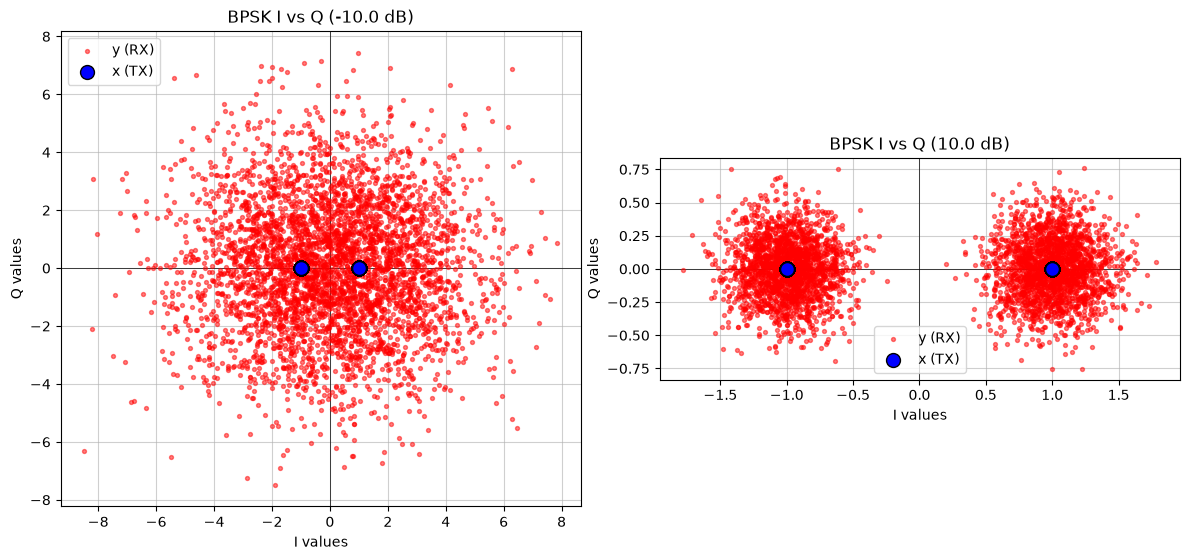

In [146]:
%matplotlib inline

plt.style.use('default')

xs_arr     = np.array(DATA['xs'])
ys_arr     = np.array(DATA['ys'])
snrs_arr   = np.array(DATA['snrs'])

snr_lo_val = snrs_arr[0]
snr_hi_val = snrs_arr[-1]

xs_lo      = xs_arr[0].flatten()
ys_lo      = ys_arr[0].flatten()

xs_hi      = xs_arr[-1].flatten()
ys_hi      = ys_arr[-1].flatten()

fig, axes  = plt.subplots(1, 2, figsize = (12, 5.5))

panels     = [
    (xs_lo, ys_lo, f"{snr_lo_val} dB"),
    (xs_hi, ys_hi, f"{snr_hi_val} dB"),
]

for ax, (x_data, y_data, title) in zip(axes, panels):

    ax.grid(True, alpha = 0.6)

    ax.axhline(0, color = 'black', linewidth = 0.5)
    ax.axvline(0, color = 'black', linewidth = 0.5)

    ax.scatter(y_data.real, y_data.imag,
               c = 'red', marker = 'o', s = 8, alpha = 0.5,
               label = 'y (RX)', zorder = 2)

    ax.scatter(x_data.real, x_data.imag,
               c = 'blue', marker = 'o', s = 100, edgecolors = 'black',
               label = 'x (TX)', zorder = 3)

    ax.set_xlabel("I values")
    ax.set_ylabel("Q values")

    ax.set_title(f"BPSK I vs Q ({title})")

    ax.legend()

    ax.set_aspect('equal', adjustable = 'box')

plt.tight_layout()
plt.show()

#### BER vs SNR curve

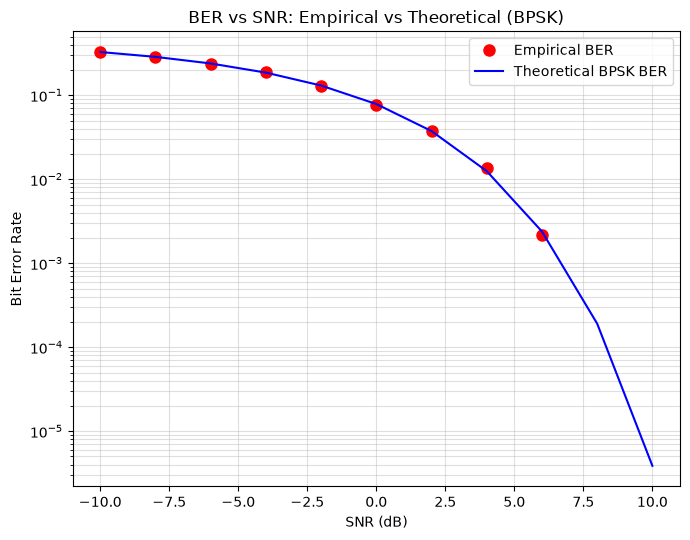

In [151]:
xs_arr      =   np.array(DATA['xs'])
ys_arr      =   np.array(DATA['ys'])
bits_arr    =   np.array(DATA['bits'])
snrs_arr    =   np.array(DATA['snrs'])

empirical_ber = []

for i in range(ys_arr.shape[0]):

    y_i          = ys_arr[i].flatten()
    bits_i       = bits_arr[i].flatten()

    decoded_bits = (y_i.real < 0).astype(bits_i.dtype)

    ber          = np.mean(decoded_bits != bits_i)

    empirical_ber.append(ber)

empirical_ber = np.array(empirical_ber)

# Theoretical BPSK BER: BER = 0.5 * erfc(sqrt(SNR_linear))
# More can be found on = https://dsplog.com/2007/08/05/bit-error-probability-for-bpsk-modulation/#gsc.tab=0
snr_linear = 10 ** (snrs_arr / 10)
theoretical_ber = 0.5 * erfc(np.sqrt(snr_linear))

fig, ax = plt.subplots(figsize = (7, 5.5))

ax.semilogy(snrs_arr, empirical_ber, 'o',
            color = 'red', markersize = 8, label = 'Empirical BER')

ax.semilogy(snrs_arr, theoretical_ber, '-',
            color = 'blue', linewidth = 1.5, label = 'Theoretical BPSK BER')

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Bit Error Rate")

ax.set_title("BER vs SNR: Empirical vs Theoretical (BPSK)")

ax.grid(True, which='both', alpha=0.4)

ax.legend()

plt.tight_layout()

plt.show()

#### Mean |LLR| vs SNR 

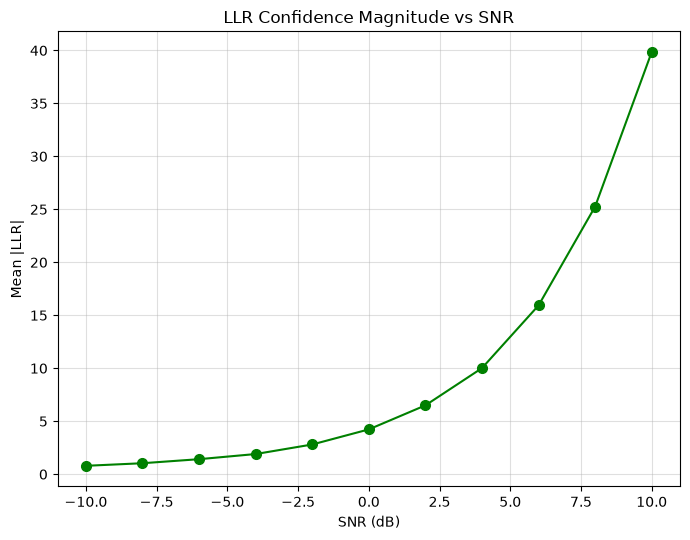

In [147]:
llr_arr      = np.array(DATA['llrs'])

mean_abs_llr = np.array([np.mean(np.abs(llr_arr[i])) 
               for i in range(llr_arr.shape[0])])

fig, ax      = plt.subplots(figsize=(7, 5.5))

ax.plot(snrs_arr, mean_abs_llr, 'o-', 
        color = 'green', linewidth = 1.5, markersize = 7)

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Mean |LLR|")

ax.set_title("LLR Confidence Magnitude vs SNR")

ax.grid(True, alpha = 0.4)

plt.tight_layout()

plt.show()

## **CONCLUSION**

The AMR-extended PHYSys export pipeline was validated against the expected output schema
`(bits, llr, snr_levels, x, y)` for the BPSK modulation sweep in `sweep.h5`.

**Verification performed (full 11-point SNR sweep, all 4 trials per point):**

1. **Structural integrity** - No NaNs or Infs anywhere in x or y. BPSK purity confirmed
   exactly (max|imag(x)| = 0.0) across the entire array, not just endpoint SNR values.

2. **Signal power** x is unit-power normalized ($mean|x|^2 = 1.0000$) at every SNR index.

3. **Noise scaling** Measured noise standard deviation matches the theoretical AWGN std
   derived from each SNR(dB) value to within ~2% at every point in the sweep 
   (N = 4096 samples per SNR point).

4. **Trial independence** - No duplicate trials found across the 4 repeats per SNR point.

5. **Bit balance** — Transmitted bits are balanced (~49.5–50.5% ones) at every SNR index,
   confirming an unbiased bit source.

6. **LLR/bit alignment** Mean |LLR| grows monotonically with SNR (0.79 -> 39.85), and
   LLR sign based hard decisions converge toward perfect agreement with bits at high SNR
   once the correct sign convention was identified.

7. **BER validation** Empirical bit error rate (hard-decoded from y) tracks the
   theoretical BPSK BER curve

**Overall:** the AMR-extended export pipeline produces a correctly structured, correctly
scaled, and internally consistent BPSK dataset. No evidence of a pipeline bug was found.